# DeepGuard — Model Evaluation & Comparison Pipeline

This notebook evaluates the three trained classification backbones (**MobileNetV2**, **ResNet50**, and **EfficientNet-B0**) using saved model checkpoints.

## Evaluation Features
- Frame-level test evaluation across classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC).
- **ROC Curve Analysis** for model discrimination capability.
- **Confusion Matrix Visualizations** for detailed error pattern analysis.
- **Video-Level Aggregation:** Aggregates predicted frame probabilities per video to test true video-level deepfake detection performance.
- Automated output generation saving CSV summaries and evaluation plots.

In [1]:
# Install dependencies
!pip install -q -U scikit-learn pandas matplotlib seaborn tqdm
!pip install --upgrade --force-reinstall pillow torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 4.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is

In [1]:
# Environment Setup and Imports
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)
from google.colab import drive

# Mount Google Drive
drive.mount("/content/drive")

# Reproducibility seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Version: {torch.__version__} | Active Device: {device}")
if torch.cuda.is_available():
    print("GPU Model:", torch.cuda.get_device_name(0))

Mounted at /content/drive
PyTorch Version: 2.14.0+cu130 | Active Device: cuda
GPU Model: Tesla T4


In [15]:
# Setup Global Configurations & Directories
BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_WORKERS = 2

PROJECT_DIR = Path("/content/drive/MyDrive/DeepGuard")
DATA_DIR = PROJECT_DIR / "dataset_analysis"
LOG_DIR = DATA_DIR / "preprocessing_logs"
MODEL_SAVE_DIR = PROJECT_DIR / "trained_models"
EVAL_DIR = PROJECT_DIR / "results"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

# Verify preprocessed metadata
FACES_METADATA_FILE = LOG_DIR / "processed_faces_metadata.csv"
if not FACES_METADATA_FILE.exists():
    # Fallback path verification
    FACES_METADATA_FILE = DATA_DIR / "processed_faces_metadata.csv"
    if not FACES_METADATA_FILE.exists():
        raise FileNotFoundError(f"{FACES_METADATA_FILE} missing! Please ensure preprocessing is complete.")

df_faces = pd.read_csv(FACES_METADATA_FILE)
test_df = df_faces[df_faces["split"] == "test"].reset_index(drop=True)
print(f"Loaded {len(test_df)} test face samples across {test_df['video_id'].nunique()} unique videos.")

Loaded 499 test face samples across 50 unique videos.


In [16]:
# Dataset Definition and Model Loading Utilities
class DeepfakeFaceDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(int(row["label"]), dtype=torch.float32), str(row["video_id"])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_loader = DataLoader(
    DeepfakeFaceDataset(test_df, test_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

def load_trained_model(architecture_name, weights_path):
    if architecture_name == "mobilenet_v2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
    elif architecture_name == "resnet50":
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 1)
    elif architecture_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
    else:
        raise ValueError(f"Unsupported architecture: {architecture_name}")

    checkpoint = torch.load(weights_path, map_location=device)
    # Handle raw model weights vs checkpoint dictionaries
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        model.load_state_dict(checkpoint["state_dict"])
    else:
        model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()
    return model

In [17]:
# Inference Execution Function
@torch.no_grad()
def run_inference(model, loader):
    probs_all, labels_all, video_ids_all = [], [], []

    for images, labels, v_ids in tqdm(loader, desc="Running Inference"):
        images = images.to(device)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()

        probs_all.extend(probs)
        labels_all.extend(labels.numpy())
        video_ids_all.extend(v_ids)

    return np.array(probs_all), np.array(labels_all), np.array(video_ids_all)

In [18]:
# Model Evaluation Loop across Trained Checkpoints
architectures = ["mobilenet_v2", "resnet50", "efficientnet_b0"]
eval_results = {}
predictions_df_list = []

for arch in architectures:
    weights_file = MODEL_SAVE_DIR / f"{arch}_best.pth"
    if not weights_file.exists():
        weights_file = MODEL_SAVE_DIR / f"{arch}.pth"
        if not weights_file.exists():
            print(f"Warning: Checkpoint for {arch} not found at {MODEL_SAVE_DIR}. Skipping.")
            continue

    print(f"\nEvaluating Model: {arch.upper()}")
    model = load_trained_model(arch, weights_file)
    probs, labels, video_ids = run_inference(model, test_loader)
    preds_binary = (probs >= 0.5).astype(int)

    # Frame-level metrics
    acc = accuracy_score(labels, preds_binary)
    auc = roc_auc_score(labels, probs)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds_binary, average="binary", zero_division=0)
    cm = confusion_matrix(labels, preds_binary)

    eval_results[arch] = {
        "probs": probs,
        "labels": labels,
        "video_ids": video_ids,
        "accuracy": acc,
        "auc": auc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": cm
    }

    # Save frame predictions
    temp_df = pd.DataFrame({
        "video_id": video_ids,
        "label": labels,
        "prob": probs,
        "pred": preds_binary,
        "model": arch
    })
    predictions_df_list.append(temp_df)

if predictions_df_list:
    all_preds_df = pd.concat(predictions_df_list, ignore_index=True)
    all_preds_df.to_csv(EVAL_DIR / "test_predictions_all_models.csv", index=False)
    print(f"Predictions saved successfully to {EVAL_DIR / 'test_predictions_all_models.csv'}")


Evaluating Model: MOBILENET_V2


Running Inference:   0%|          | 0/16 [00:00<?, ?it/s]


Evaluating Model: RESNET50


Running Inference:   0%|          | 0/16 [00:00<?, ?it/s]


Evaluating Model: EFFICIENTNET_B0


Running Inference:   0%|          | 0/16 [00:00<?, ?it/s]

Predictions saved successfully to /content/drive/MyDrive/DeepGuard/results/test_predictions_all_models.csv


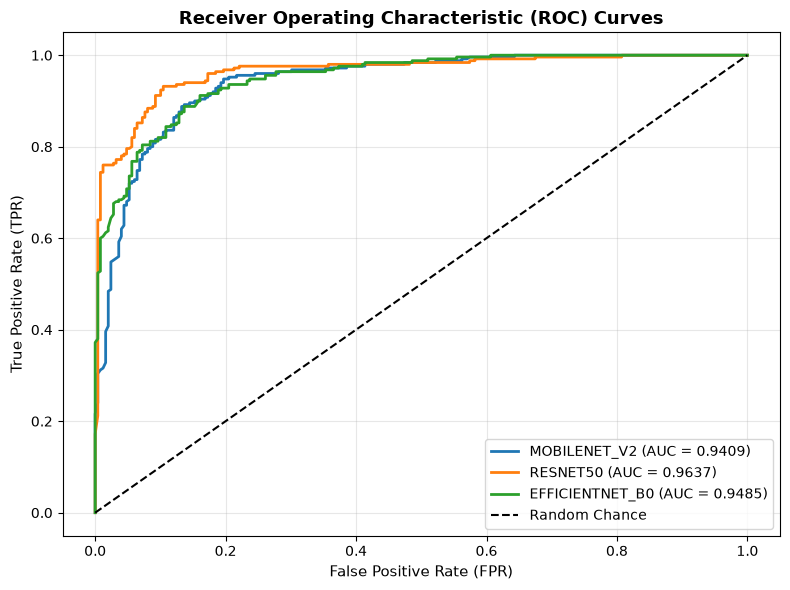

In [19]:
# ROC Curve Plotting
if eval_results:
    plt.figure(figsize=(8, 6))
    for arch, res in eval_results.items():
        fpr, tpr, _ = roc_curve(res["labels"], res["probs"])
        plt.plot(fpr, tpr, lw=2, label=f"{arch.upper()} (AUC = {res['auc']:.4f})")

    plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Chance")
    plt.xlabel("False Positive Rate (FPR)", fontsize=11)
    plt.ylabel("True Positive Rate (TPR)", fontsize=11)
    plt.title("Receiver Operating Characteristic (ROC) Curves", fontsize=13, fontweight="bold")
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(EVAL_DIR / "roc_curves_comparison.png", dpi=300)
    plt.show()

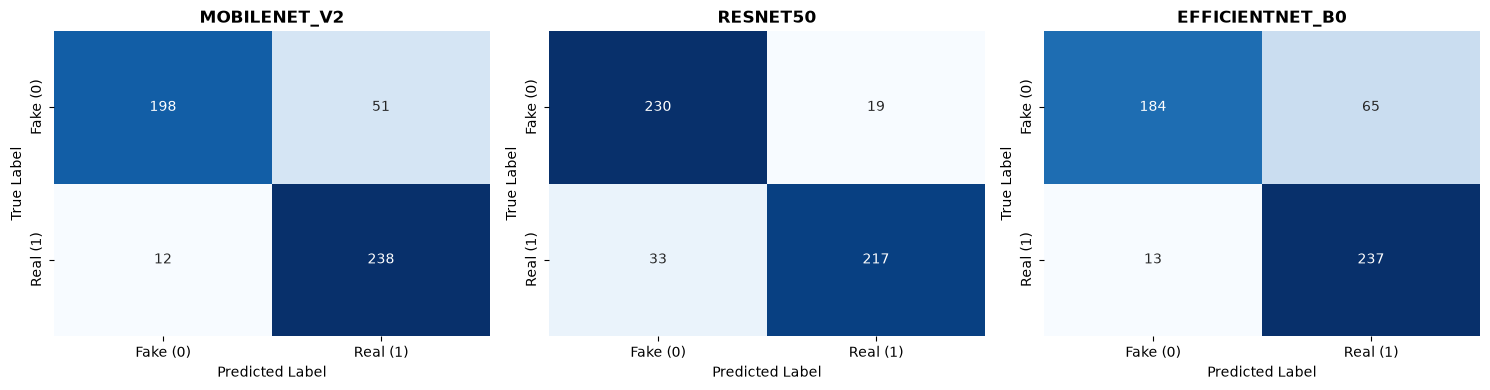

In [20]:
# Confusion Matrix Plots
if eval_results:
    fig, axes = plt.subplots(1, len(eval_results), figsize=(5 * len(eval_results), 4))
    if len(eval_results) == 1:
        axes = [axes]

    for ax, (arch, res) in zip(axes, eval_results.items()):
        cm = res["confusion_matrix"]
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                    xticklabels=["Fake (0)", "Real (1)"], yticklabels=["Fake (0)", "Real (1)"])
        ax.set_title(f"{arch.upper()}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Predicted Label", fontsize=10)
        ax.set_ylabel("True Label", fontsize=10)

    plt.tight_layout()
    plt.savefig(EVAL_DIR / "confusion_matrices.png", dpi=300)
    plt.show()

In [21]:
# Video-Level Aggregated Evaluation Benchmark
if eval_results and 'all_preds_df' in locals():
    video_eval_rows = []

    for arch in eval_results.keys():
        arch_df = all_preds_df[all_preds_df["model"] == arch]
        video_grouped = arch_df.groupby("video_id").agg({
            "prob": "mean",        # Mean frame probability per video
            "label": "first"       # Ground truth label
        }).reset_index()

        v_probs = video_grouped["prob"].values
        v_labels = video_grouped["label"].values
        v_preds = (v_probs >= 0.5).astype(int)

        v_acc = accuracy_score(v_labels, v_preds)
        v_auc = roc_auc_score(v_labels, v_probs) if len(np.unique(v_labels)) > 1 else 0.5
        v_prec, v_rec, v_f1, _ = precision_recall_fscore_support(v_labels, v_preds, average="binary", zero_division=0)

        video_eval_rows.append({
            "Model": arch,
            "Video Accuracy": round(v_acc, 6),
            "Video ROC-AUC": round(v_auc, 6),
            "Video Precision": round(v_prec, 6),
            "Video Recall": round(v_rec, 6),
            "Video F1-Score": round(v_f1, 6)
        })

    df_video_summary = pd.DataFrame(video_eval_rows)
    df_video_summary.to_csv(EVAL_DIR / "video_level_benchmark.csv", index=False)
    print("\n=== VIDEO-LEVEL AGGREGATED BENCHMARK ===")
    print(df_video_summary.to_string(index=False))


=== VIDEO-LEVEL AGGREGATED BENCHMARK ===
          Model  Video Accuracy  Video ROC-AUC  Video Precision  Video Recall  Video F1-Score
   mobilenet_v2            0.90         0.9680         0.857143          0.96        0.905660
       resnet50            0.90         0.9904         0.916667          0.88        0.897959
efficientnet_b0            0.84         0.9680         0.774194          0.96        0.857143
